In [1]:
# cargar el paquete
using DCMotor

# definicion del sistema
sys = MotorSystem();

[ Info: Precompiling DCMotor [922c4102-36b8-43cd-8715-15eb17fb0f46] (cache misses: include_dependency fsize change (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


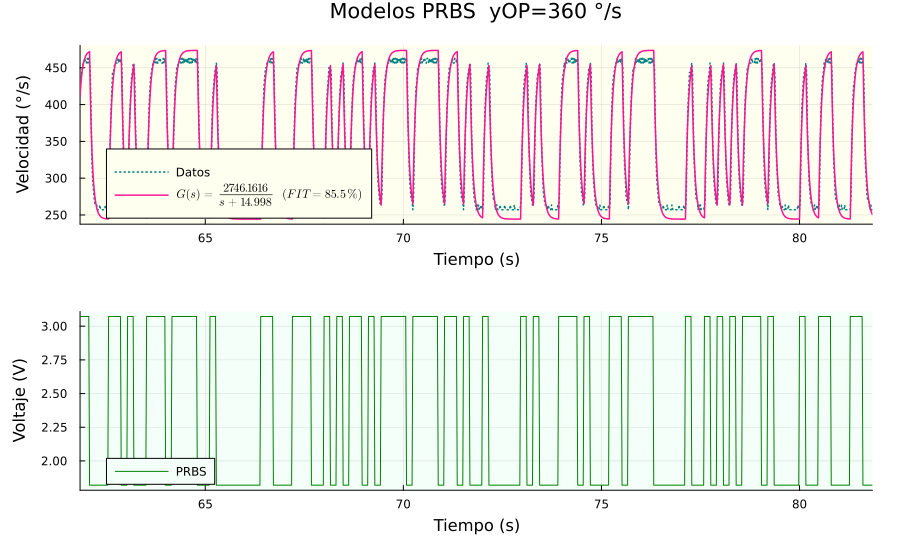

In [ ]:
# modelo estático
uee, yee = get_static_model(sys)

# identificacion del sistema
G = get_model_prbs(sys; yop=360,sigma=100);

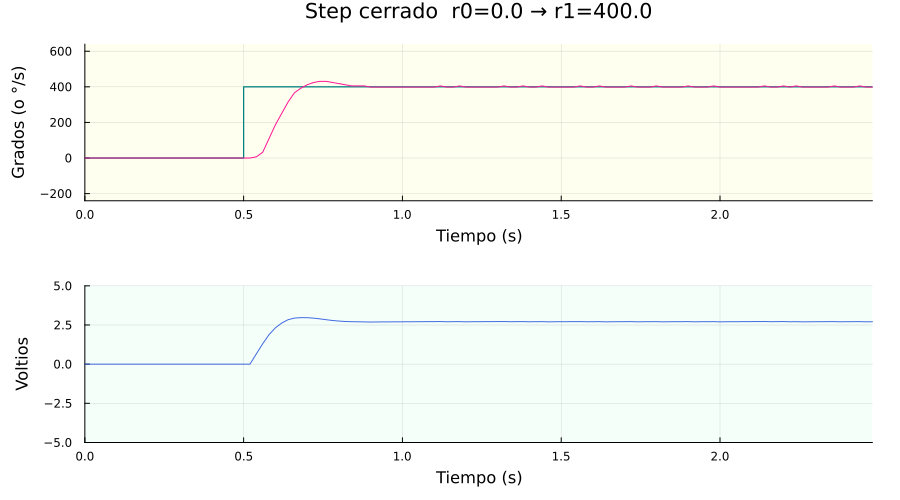

Referencia fijada a 0.00 



In [2]:
G=tf(sys, :speed)
a = denvec(G)[1][2]
b = numvec(G)[1][1]
ωn=15
ζ = 0.7
# calculo de las constantes
Kp = (2*ζ*ωn-a)/b
Ki = ωn^2/b
s=tf("s")


G1  = feedback(G,Kp)
T= feedback(G1*Ki/s,1)
set_pid(sys;  kp=Kp, ki=Ki, kd=0, beta=0, output=:speed)
result = step_closed(sys; r0 = 0, r1 =400,  t0 = 0.5, t1 =2); 

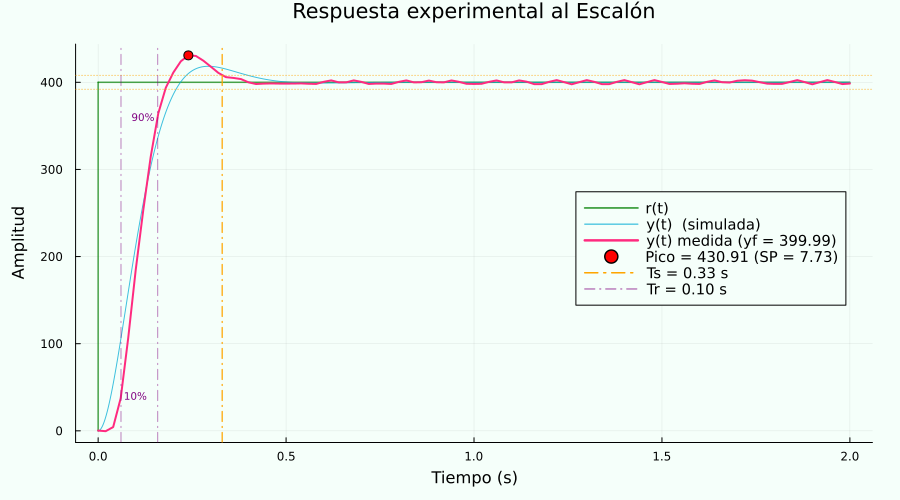

Info Resp. Escalón:
  Valor inicial:        0.000
  Valor final:        399.986
  Cambio escalón:     400.000
  Pico:               430.912
  Tiempo pico:          0.240 s
  Sobrepico:             7.73 %
  T. estabilización:    0.330 s
  T. subida:            0.097 s
  Max. |u(t)|:          2.968 V


In [3]:
stepinfo(result,T)